In [31]:
import json

def count_chars(filename):
    with open(filename) as f:
        nb = json.load(f)
    
    counts = {'code': 0, 'markdown': 0, 'raw': 0, 'other': 0}
    
    for cell in nb['cells']:
        cell_type = cell['cell_type']
        chars = sum(len(line) for line in cell['source'])
        if cell_type in counts:
            counts[cell_type] += chars
        else:
            counts['other'] += chars
    
    total = sum(counts.values())
    
    for cell_type in ['code', 'markdown', 'raw', 'other']:
        print(f"{cell_type},{counts[cell_type]}")
    
    print(f"total,{total}")
    
    if total > 75000:
        print("Too many characters in assignment submission (> 75,000)")
    else:
        print("Number of characters ok ( < 75,000)")

count_chars('Task-2.ipynb')

code,5224
markdown,6655
raw,0
other,0
total,11879
Number of characters ok ( < 75,000)


## Table of Contents
1. [Introduction](#10-introduction)
2. [Python Libraries and their sources](#11-python-libraries-and-their-sources)
3. [Import Required Libraries](#12-import-required-libraries)
4. [Part A: Multiple Linear Regression (Dataset 2)](#13-part-a-multiple-linear-regression-dataset-2)
   1. [Algorithm Deep Dive: The Hyperplane](#131-algorithm-deep-dive-the-hyperplane)
   2. [Data Loading & Visual Review](#132-data-loading--visual-review)  
   3. [Building and Evaluating the MLR Model](#133-building-and-evaluating-the-mlr-model)
5. [Part B: Polynomial Regression (Dataset 1)](#14-part-b-polynomial-regression-dataset-1)
   1. [Algorithm Deep Dive: Feature Engineering](#141-algorithm-deep-dive-feature-engineering)
   2. [Visualizing the Linear Baseline Failure](#142-visualizing-the-linear-baseline-failure)
   3. [Building and Evaluating the Polynomial Model](#143-building-and-evaluating-the-polynomial-model)
6. [The Danger Zone: Runge's Phenomenon](#15-the-danger-zone-runges-phenomenon)
7. [Final Thoughts](#16-final-thoughts)

## 1.0 Introduction
In the real world, target variables are rarely driven by a single feature, nor do they strictly adhere to straight lines.

In this tutorial, we will review `multivariate and polynomial` expansions of the linear model.

From Task-1, we found that the `Polynomial Regression was the best fit model for Dataset-1` and `Multiple Linear Regression was the best fit model for Dataset-2`.

**The Core Academic Insight:**
As we will explore in this tutorial, **Multiple Linear Regression** and **Polynomial Regression** are mathematically identical under the hood. They both rely on the Ordinary Least Squares (OLS) algorithm. The difference lies entirely in how we structure the input data *before* feeding it to the algorithm. Let's dive in.

### 1.1 Python libraries and their sources:

As part of the assignment, I have used the below listed Python libraries:

1. pandas - Python Data Analytics Library
   
    - https://pandas.pydata.org/

2. numpy - Scientific computing with Python

    - https://numpy.org/

3. missingno - Visualising missing data in dataframes

    - https://github.com/ResidentMario/missingno

4. scikit-learn - Machine Learning Library for Python

    - https://scikit-learn.org/stable/

5. matplotlib - Visualisation with Python

    - https://matplotlib.org/

6. seaborn - Statistical data visualisation

    - https://seaborn.pydata.org/

## 1.2 Import Required Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Visualization
from matplotlib.pyplot import figure
from pandas.plotting import scatter_matrix

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Set display precision for pandas tables (Standard pedagogical practice)
pd.set_option('display.precision', 2)
sns.set_theme(style="whitegrid")

## 1.3 Part A: Multiple Linear Regression (Dataset 2)

### 1.3.1 Algorithm Deep Dive: The Hyperplane
In Simple Linear Regression, we fit a 2D line defined by $y = mx + c$. But what happens when our target ($y$) depends on multiple independent features ($x_1, x_2, \dots, x_n$)? 

**The Algorithm:**
Multiple Linear Regression (MLR) expands the equation to fit a multi-dimensional **hyperplane**. The general equation is:
$$y = \theta_0x_0 + \theta_1x_1 + \theta_2x_2 + \dots + \theta_nx_n + \epsilon$$
*(Where $x_0 = 1$ to represent the intercept, $\theta$ represents the learned weights, and $\epsilon$ is the error).*

**How it Learns:**
The algorithm uses a method called **Ordinary Least Squares (OLS)**. It looks at the multidimensional cloud of data points and calculates the exact tilt and elevation of a rigid "sheet" (the hyperplane) that minimizes the total squared distance between the sheet and every single data point. 

### 1.3.2 Data Loading & Visual Review
Let's look at Dataset 2. It has two features ($X_1, X_2$). We will plot it in 3D space to verify that the data forms a relatively flat, tilted "sheet," validating our choice to use the MLR algorithm.

Dataset 2 Shape: (600, 3)


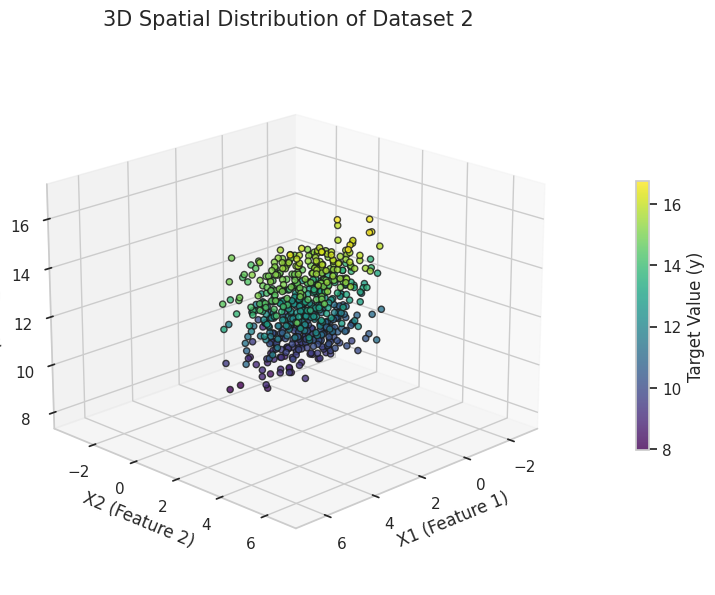

In [33]:
# Load Dataset 2
df2 = pd.read_csv('CML_2026-01-26#5-dataset_2.csv')

print(f"Dataset 2 Shape: {df2.shape}")

# 3D Scatter Plot for Spatial Review
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Color map tied to 'y' to aid depth perception
scatter = ax.scatter(df2['X1'], df2['X2'], df2['y'], c=df2['y'], cmap='viridis', alpha=0.8, edgecolor='k')

ax.set_title("3D Spatial Distribution of Dataset 2", fontsize=15, pad=15)
ax.set_xlabel("X1 (Feature 1)")
ax.set_ylabel("X2 (Feature 2)")
ax.set_zlabel("y (Target)")
plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1, label='Target Value (y)')
ax.view_init(elev=20, azim=45)
plt.show()


> **_Note:_** The 3D plot confirms the data is dispersed across a flat, tilted plane. We can now safely partition the data into training and testing sets and apply our MLR algorithm.

### 1.3.3 Building and Evaluating the MLR Model
Notice that in `scikit-learn`, we simply pass a dataframe with multiple columns into the standard `LinearRegression()` object. The algorithm automatically detects the multiple dimensions and calculates the hyperplane.

MLR R^2 Score (Goodness of Fit): 0.8063
MLR Mean Squared Error:          0.95


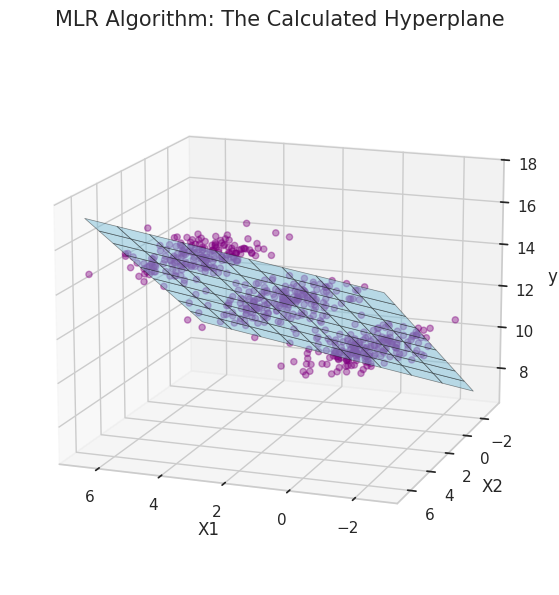

In [34]:
# Train/Test Split
X2_features = df2[['X1', 'X2']]
y2_target = df2['y']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_features, y2_target, test_size=0.2, random_state=42)

# Build and Train the MLR Model
mlr_model = LinearRegression()
mlr_model.fit(X2_train, y2_train)

# Evaluate
y2_pred = mlr_model.predict(X2_test)
print(f"MLR R^2 Score (Goodness of Fit): {r2_score(y2_test, y2_pred):.4f}")
print(f"MLR Mean Squared Error:          {mean_squared_error(y2_test, y2_pred):.2f}")

# Visualize the Calculated Hyperplane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df2['X1'], df2['X2'], df2['y'], color='purple', alpha=0.4, label='Raw Data')

# Generate a dense mathematical grid to represent the calculated plane
x1_grid, x2_grid = np.meshgrid(np.linspace(df2['X1'].min(), df2['X1'].max(), 10),
                               np.linspace(df2['X2'].min(), df2['X2'].max(), 10))
y_plane = mlr_model.predict(pd.DataFrame({'X1': x1_grid.ravel(), 'X2': x2_grid.ravel()}))
y_plane = y_plane.reshape(x1_grid.shape)

# Overlay the plane
ax.plot_surface(x1_grid, x2_grid, y_plane, color='skyblue', alpha=0.5, edgecolor='k', linewidth=0.5)

ax.set_title("MLR Algorithm: The Calculated Hyperplane", fontsize=15, pad=15)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.view_init(elev=15, azim=110)
plt.show()

## 1.4 Part B: Polynomial Regression (Dataset 1)

### 1.4.1 Algorithm Deep Dive: Feature Engineering
What happens when a dataset has only *one* feature, but the relationship forms a curve? 

**The Algorithm:**
Polynomial Regression is a brilliant mathematical trick. It is actually a **Linear** model. The algorithm is the exact same OLS algorithm we just used above. The secret lies in **Feature Engineering**. 

Instead of forcing a straight line through a curve, we artificially expand our single feature ($x_1$) by squaring or cubing it. The equation becomes:
$$y = \theta_0x_0 + \theta_1x_1 + \theta_2x_1^2 + \theta_3x_1^3 + \epsilon$$

**How it Learns:**
Look at the equation above. To the linear algorithm, $x_1^2$ and $x_1^3$ are treated as completely new, independent variables (exactly like $X_2$ and $X_3$ in our MLR model). The algorithm calculates weights for these polynomial features, and when those features are plotted back onto a 2D graph, they create a perfect, smooth curve!

### 1.4.2 Visualizing the Linear Baseline Failure
Let's load Dataset 1 (a U-shaped curve) and attempt to fit a standard linear line to it. This will result in **High Bias (Underfitting)**.

Baseline Linear R^2 Score: 0.4118 (Very Poor)


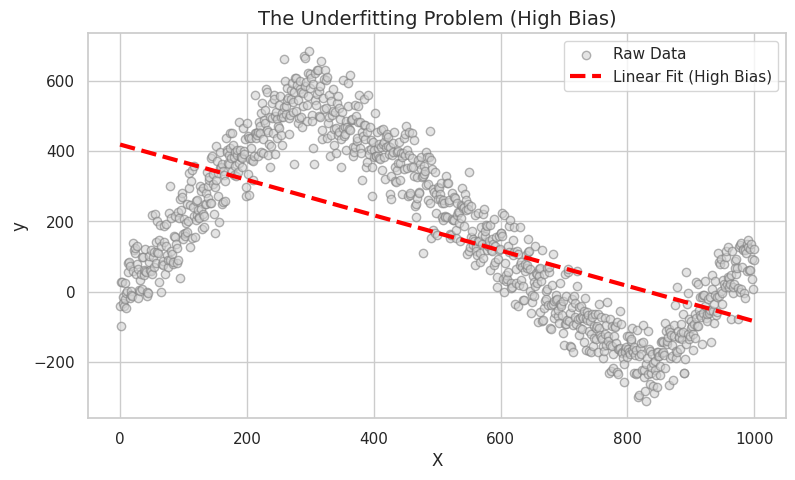

In [35]:
# Load Dataset 1
df1 = pd.read_csv('CML_2026-01-26#4-dataset_1.csv')
X1 = df1[['X']]
y1 = df1['y']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Train Baseline Linear Model
baseline_lr = LinearRegression()
baseline_lr.fit(X1_train.values, y1_train.values)

# Evaluate Failure
y1_pred_base = baseline_lr.predict(X1_test.values)
print(f"Baseline Linear R^2 Score: {r2_score(y1_test, y1_pred_base):.4f} (Very Poor)")

# Visualize Underfitting
X1_smooth = np.linspace(X1.min(), X1.max(), 500).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.scatter(X1, y1, color='lightgray', label='Raw Data', alpha=0.6, edgecolor='gray')
plt.plot(X1_smooth, baseline_lr.predict(X1_smooth), color='red', linewidth=3, linestyle='--', label='Linear Fit (High Bias)')
plt.title("The Underfitting Problem (High Bias)", fontsize=14)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### 1.4.3 Building and Evaluating the Polynomial Model
We will use `PolynomialFeatures(degree=3)` to mathematically engineer $X^2$ and $X^3$. By chaining this directly into `LinearRegression()` using a pipeline, we allow the algorithm to "bend."

Polynomial (Degree 3) R^2 Score: 0.9249 (Excellent Fit)
Polynomial (Degree 3) MSE:       4500.11


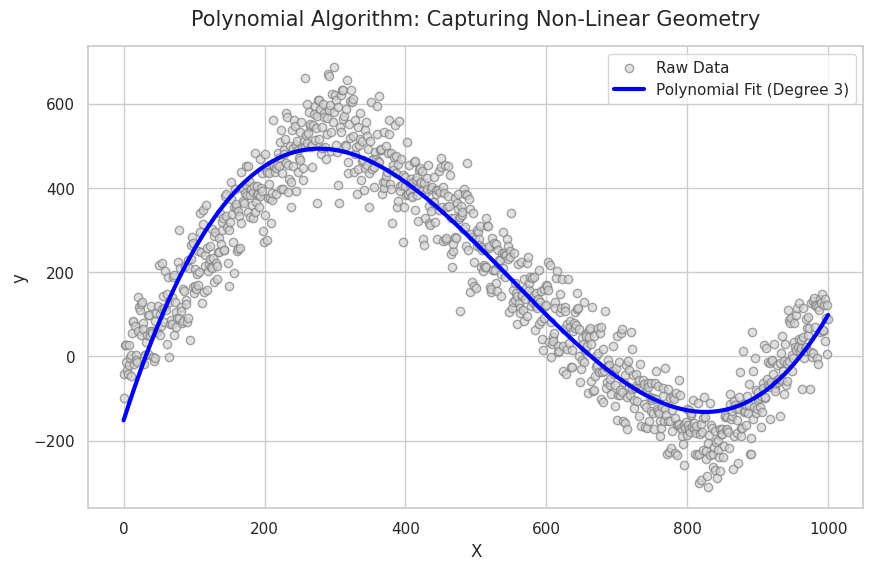

In [36]:
# 1. Build the Pipeline (Degree 3)
poly_pipeline = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# 2. Train the Pipeline
poly_pipeline.fit(X1_train.values, y1_train.values)

# 3. Evaluate Success
y1_pred_poly = poly_pipeline.predict(X1_test.values)
print(f"Polynomial (Degree 3) R^2 Score: {r2_score(y1_test, y1_pred_poly):.4f} (Excellent Fit)")
print(f"Polynomial (Degree 3) MSE:       {mean_squared_error(y1_test, y1_pred_poly):.2f}")

# 4. Visualize the Curve
plt.figure(figsize=(10, 6))
plt.scatter(X1, y1, color='lightgray', label='Raw Data', alpha=0.7, edgecolor='gray')

# Plot the smooth polynomial prediction
plt.plot(X1_smooth, poly_pipeline.predict(X1_smooth), color='blue', linewidth=3, label='Polynomial Fit (Degree 3)')

plt.title("Polynomial Algorithm: Capturing Non-Linear Geometry", fontsize=15, pad=15)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 1.5 The Danger Zone: Runge's Phenomenon
If a 3rd-degree polynomial provides an excellent fit, novice data scientists often assume a 15th-degree polynomial will be flawless. **This is mathematically catastrophic.**

When we push the degree too high, the model gains excessive parametric flexibility. Rather than drawing a smooth macroscopic curve *through* the center of mass, the line will violently oscillate to touch every single random noise artifact in the training set. This is known as **Runge's Phenomenon**, or **High Variance (Overfitting)**. The model memorizes the noise, destroying its ability to predict new test data.

## 1.6 Final Thoughts
As demonstrated throughout this workbook:
* The core OLS (Ordinary Least Squares) algorithm is incredibly versatile. 
* By structuring our raw data differently—either by including multiple distinct real-world variables (Dataset 2) or by mathematically squaring a single variable (Dataset 1)—we can map multi-dimensional planes and complex curves with the exact same mathematical engine.
* However, with great parametric flexibility comes the great responsibility of preventing overfitting!